In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import table
import io
import dataframe_image as dfi
import seaborn as sns

from pathlib import Path

# Define paths
DATA_PATH = Path("../../../../data/raw")



🔍 MEDICAL OUTLIER ANALYSIS: 'Birth_Weight(grams)'

📌 DATASET OVERVIEW:
   • Total records: 301,712
   • Valid records: 268,170
   • Missing values: 33,542 (11.1%)
   • Data type: float64

────────────────────────────────────────────────────────────────────────────────
📋 STEP 2: MEDICAL THRESHOLDS
────────────────────────────────────────────────────────────────────────────────

   Variable: Birth_Weight(grams)
   Medical Reference: 1770.0 - 4090.0 (statistical)
   Unit: units

   Medical Categories:
      • Extreme Low: 620.0 - 900.0 units
      • Low: 900.0 - 1,770.0 units
      • Normal Range: 1,770.0 - 4,090.0 units
      • High: 4,090.0 - 4,960.0 units
      • Extreme High: 4,960.0 - 7,740.0 units

────────────────────────────────────────────────────────────────────────────────
📊 STEP 3: CLASSIFYING RECORDS
────────────────────────────────────────────────────────────────────────────────

📋 CLASSIFICATION SUMMARY:
detailed_category   category  Count    Mean    Min    Max
     Extrem

C:\Users\DELL\AppData\Local\Temp\ipykernel_20012\2488723673.py:274: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
C:\Users\DELL\AppData\Local\Temp\ipykernel_20012\2488723673.py:287: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


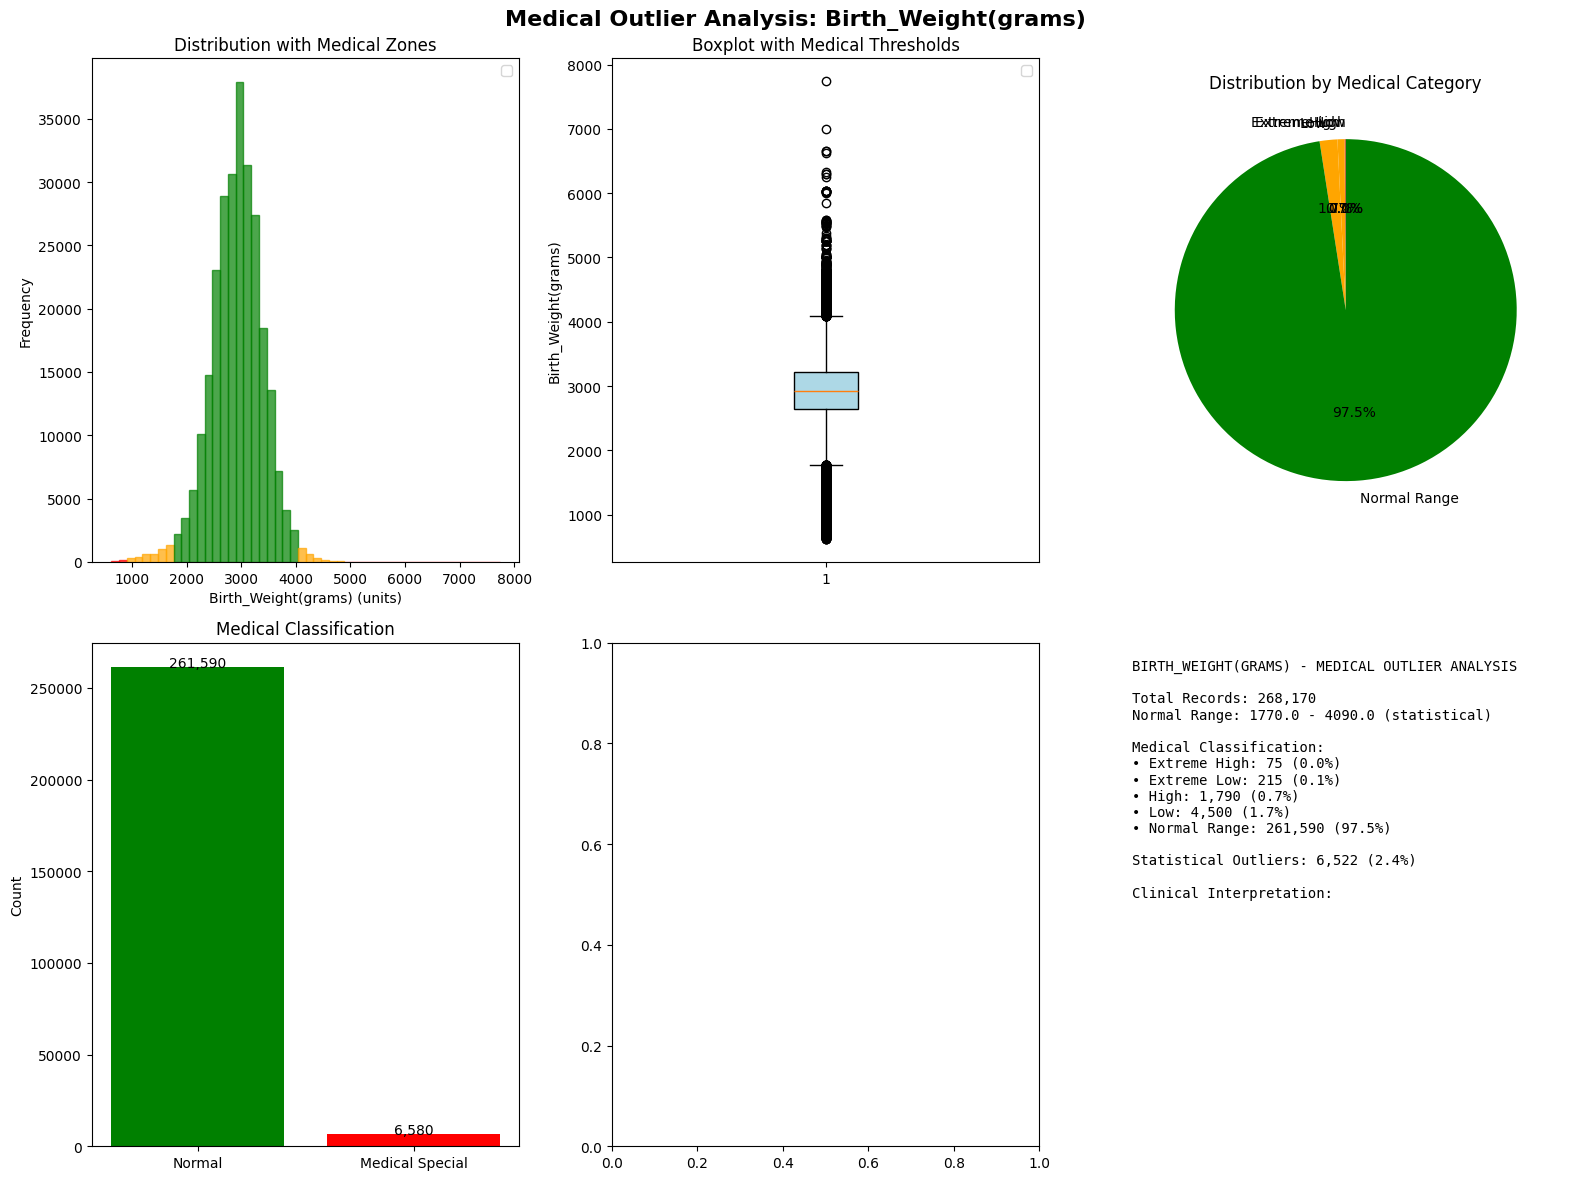

✅ Saved: Birth_Weight(grams)_medical_outliers.png

────────────────────────────────────────────────────────────────────────────────
📊 STEP 7: EXPORTING TO EXCEL
────────────────────────────────────────────────────────────────────────────────
✅ Excel file saved: Birth_Weight(grams)_medical_outliers.xlsx

✅ MEDICAL OUTLIER ANALYSIS COMPLETE

📁 FILES CREATED:
   • PNG: Birth_Weight(grams)_medical_outliers.png
   • Excel: Birth_Weight(grams)_medical_outliers.xlsx

📊 KEY FINDINGS:
   • Total valid records: 268,170
   • Normal range: 1770.0 - 4090.0 (statistical)
   • Extreme High: 75 (0.0%)
   • Extreme Low: 215 (0.1%)
   • High: 1,790 (0.7%)
   • Low: 4,500 (1.7%)
   • Normal Range: 261,590 (97.5%)


In [5]:


# ============================================
# STEP 1: DEFINE YOUR TARGET VARIABLE HERE
# ============================================
TARGET = 'Birth_Weight(grams)'  # <--- CHANGE THIS to analyze different variables
# ============================================

print(f"\n{'='*80}")
print(f"🔍 MEDICAL OUTLIER ANALYSIS: '{TARGET}'")
print(f"{'='*80}")

# Check if column exists
if TARGET not in df.columns:
    print(f"❌ ERROR: Column '{TARGET}' not found!")
    exit()

# Get data
data = df[TARGET].dropna()
original_data = df[TARGET]  # Keep with missing

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records: {len(original_data):,}")
print(f"   • Valid records: {len(data):,}")
print(f"   • Missing values: {original_data.isnull().sum():,} ({(original_data.isnull().sum()/len(original_data)*100):.1f}%)")
print(f"   • Data type: {data.dtype}")

# ============================================
# STEP 2: DEFINE MEDICAL THRESHOLDS
# ============================================
print(f"\n{'─'*80}")
print(f"📋 STEP 2: MEDICAL THRESHOLDS")
print(f"{'─'*80}")

# Define thresholds based on variable type
if TARGET.lower() in ['birth_weight', 'weight', 'birthweight', 'bw']:
    # Birth weight thresholds (WHO)
    thresholds = {
        'Extremely Low Birth Weight': {'min': 0, 'max': 999, 'color': 'darkred', 'category': 'Critical'},
        'Very Low Birth Weight': {'min': 1000, 'max': 1499, 'color': 'red', 'category': 'Very Low'},
        'Low Birth Weight': {'min': 1500, 'max': 2499, 'color': 'orange', 'category': 'Low'},
        'Normal Birth Weight': {'min': 2500, 'max': 4499, 'color': 'green', 'category': 'Normal'},
        'High Birth Weight (Macrosomia)': {'min': 4500, 'max': 4999, 'color': 'orange', 'category': 'High'},
        'Very High Birth Weight': {'min': 5000, 'max': 99999, 'color': 'red', 'category': 'Very High'}
    }
    unit = 'grams'
    normal_range = "2,500 - 4,499 grams"
    
elif TARGET.lower() in ['gestation_weeks', 'gestation', 'gestational_age']:
    # Gestational age thresholds
    thresholds = {
        'Extremely Preterm': {'min': 0, 'max': 27, 'color': 'darkred', 'category': 'Critical'},
        'Very Preterm': {'min': 28, 'max': 31, 'color': 'red', 'category': 'Very Preterm'},
        'Moderate to Late Preterm': {'min': 32, 'max': 36, 'color': 'orange', 'category': 'Preterm'},
        'Early Term': {'min': 37, 'max': 38, 'color': 'lightgreen', 'category': 'Early Term'},
        'Full Term': {'min': 39, 'max': 40, 'color': 'green', 'category': 'Full Term'},
        'Late Term': {'min': 41, 'max': 41, 'color': 'lightgreen', 'category': 'Late Term'},
        'Post Term': {'min': 42, 'max': 99, 'color': 'orange', 'category': 'Post Term'}
    }
    unit = 'weeks'
    normal_range = "39 - 40 weeks (Full Term)"
    
elif TARGET.lower() in ['mother_age', 'maternal_age', 'age_mother']:
    # Maternal age thresholds
    thresholds = {
        'Very Young': {'min': 0, 'max': 15, 'color': 'orange', 'category': 'High Risk'},
        'Adolescent': {'min': 16, 'max': 19, 'color': 'yellow', 'category': 'Moderate Risk'},
        'Optimal': {'min': 20, 'max': 34, 'color': 'green', 'category': 'Optimal'},
        'Advanced Maternal Age': {'min': 35, 'max': 40, 'color': 'yellow', 'category': 'Moderate Risk'},
        'Very Advanced': {'min': 41, 'max': 99, 'color': 'orange', 'category': 'High Risk'}
    }
    unit = 'years'
    normal_range = "20 - 34 years"
    
else:
    # Generic statistical thresholds
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    thresholds = {
        'Extreme Low': {'min': data.min(), 'max': q1 - 3*iqr, 'color': 'red', 'category': 'Outlier'},
        'Low': {'min': q1 - 3*iqr, 'max': q1 - 1.5*iqr, 'color': 'orange', 'category': 'Suspicious'},
        'Normal Range': {'min': q1 - 1.5*iqr, 'max': q3 + 1.5*iqr, 'color': 'green', 'category': 'Normal'},
        'High': {'min': q3 + 1.5*iqr, 'max': q3 + 3*iqr, 'color': 'orange', 'category': 'Suspicious'},
        'Extreme High': {'min': q3 + 3*iqr, 'max': data.max(), 'color': 'red', 'category': 'Outlier'}
    }
    unit = 'units'
    normal_range = f"{q1 - 1.5*iqr:.1f} - {q3 + 1.5*iqr:.1f} (statistical)"

print(f"\n   Variable: {TARGET}")
print(f"   Medical Reference: {normal_range}")
print(f"   Unit: {unit}")
print(f"\n   Medical Categories:")
for category, details in thresholds.items():
    print(f"      • {category}: {details['min']:,} - {details['max']:,} {unit}")

# ============================================
# STEP 3: CLASSIFY EACH RECORD
# ============================================
print(f"\n{'─'*80}")
print(f"📊 STEP 3: CLASSIFYING RECORDS")
print(f"{'─'*80}")

# Create classification DataFrame
classification = []
for value in data:
    for category, details in thresholds.items():
        if details['min'] <= value <= details['max']:
            classification.append({
                'value': value,
                'category': details['category'],
                'detailed_category': category,
                'color': details['color']
            })
            break

class_df = pd.DataFrame(classification)

# Summary by category
category_summary = class_df.groupby(['detailed_category', 'category']).agg({
    'value': ['count', 'mean', 'min', 'max']
}).round(2)
category_summary.columns = ['Count', 'Mean', 'Min', 'Max']
category_summary = category_summary.reset_index()

print(f"\n📋 CLASSIFICATION SUMMARY:")
print(category_summary.to_string(index=False))

# Calculate percentages
total_valid = len(data)
print(f"\n   Total valid records: {total_valid:,}")
for _, row in category_summary.iterrows():
    pct = (row['Count'] / total_valid * 100)
    print(f"   • {row['detailed_category']}: {row['Count']:,} ({pct:.1f}%) - Mean: {row['Mean']:.1f}")

# ============================================
# STEP 4: COMPARE WITH STATISTICAL OUTLIERS
# ============================================
print(f"\n{'─'*80}")
print(f"📈 STEP 4: COMPARING WITH STATISTICAL OUTLIERS")
print(f"{'─'*80}")

# Statistical outliers (IQR method)
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

stat_outliers = data[(data < lower_fence) | (data > upper_fence)]
medical_special = data[(data < 2500) | (data > 4499)] if TARGET.lower() in ['birth_weight', 'weight'] else pd.Series()

print(f"\n   Statistical Analysis:")
print(f"      • Q1 (25th): {q1:.1f}")
print(f"      • Q3 (75th): {q3:.1f}")
print(f"      • IQR: {iqr:.1f}")
print(f"      • Lower fence: {lower_fence:.1f}")
print(f"      • Upper fence: {upper_fence:.1f}")
print(f"      • Statistical outliers: {len(stat_outliers):,} ({len(stat_outliers)/total_valid*100:.1f}%)")

print(f"\n   Medical Classification:")
if TARGET.lower() in ['birth_weight', 'weight']:
    print(f"      • Outside normal range: {len(medical_special):,} ({len(medical_special)/total_valid*100:.1f}%)")

# Find overlap (only for birth weight)
if TARGET.lower() in ['birth_weight', 'weight']:
    medical_but_not_stat = data[(data < 2500) | (data > 4499)][
        ~((data < 2500) | (data > 4499)).isin(stat_outliers)
    ]
    stat_but_not_medical = stat_outliers[
        ~stat_outliers.isin(data[(data < 2500) | (data > 4499)])
    ]
    
    print(f"\n   Comparison:")
    print(f"      • Records considered outliers by BOTH methods: {len(set(stat_outliers) & set(medical_special))}")
    print(f"      • Medical special but NOT statistical outlier: {len(medical_but_not_stat)}")
    print(f"      • Statistical outlier but medically normal: {len(stat_but_not_medical)}")

# ============================================
# STEP 5: DETAILED OUTLIER ANALYSIS
# ============================================
print(f"\n{'─'*80}")
print(f"🔬 STEP 5: DETAILED OUTLIER ANALYSIS")
print(f"{'─'*80}")

# Get medical outliers
medical_outliers = class_df[class_df['category'] != 'Normal']

if len(medical_outliers) > 0:
    print(f"\n   📊 MEDICAL OUTLIERS SUMMARY:")
    
    # By category
    for category in medical_outliers['detailed_category'].unique():
        cat_data = medical_outliers[medical_outliers['detailed_category'] == category]
        print(f"\n      {category}:")
        print(f"         • Count: {len(cat_data):,}")
        print(f"         • Range: {cat_data['value'].min():.1f} - {cat_data['value'].max():.1f}")
        print(f"         • Mean: {cat_data['value'].mean():.1f}")
        print(f"         • Median: {cat_data['value'].median():.1f}")
        
        # If birth weight, show breakdown
        if TARGET.lower() in ['birth_weight', 'weight']:
            if 'Low' in category:
                print(f"         • Clinical significance: May need NICU admission")
            elif 'High' in category:
                print(f"         • Clinical significance: Risk of birth complications")
    
    # Cross-tabulation with other variables
    print(f"\n   🔍 CROSS-TABULATION WITH OTHER VARIABLES:")
    
    # Create analysis DataFrame
    outlier_df = df.copy()
    outlier_df['is_medical_outlier'] = outlier_df[TARGET].isin(medical_outliers['value'])
    outlier_df['outlier_category'] = 'Normal'
    
    for _, row in medical_outliers.iterrows():
        outlier_df.loc[outlier_df[TARGET] == row['value'], 'outlier_category'] = row['detailed_category']
    
    # Check by gender
    if 'Gender' in outlier_df.columns:
        gender_cross = pd.crosstab(
            outlier_df['Gender'].fillna('Unknown'), 
            outlier_df['outlier_category'],
            normalize='columns'
        ) * 100
        print(f"\n      Distribution by Gender (%):")
        print(gender_cross.round(1).to_string())
    
    # Check by hospital
    if 'Hospital or Not' in outlier_df.columns:
        hospital_cross = pd.crosstab(
            outlier_df['Hospital or Not'].fillna('Unknown'), 
            outlier_df['outlier_category']
        )
        print(f"\n      Distribution by Hospital:")
        print(hospital_cross.to_string())
    
    # Check by multiple birth
    if 'Multiple_Birth_Status' in outlier_df.columns:
        multiple_cross = pd.crosstab(
            outlier_df['Multiple_Birth_Status'].fillna('Unknown'), 
            outlier_df['outlier_category'],
            normalize='columns'
        ) * 100
        print(f"\n      Distribution by Multiple Birth (%):")
        print(multiple_cross.round(1).to_string())

# ============================================
# STEP 6: VISUALIZATIONS
# ============================================
print(f"\n{'─'*80}")
print(f"🎨 STEP 6: CREATING VISUALIZATIONS")
print(f"{'─'*80}")

fig = plt.figure(figsize=(16, 12))

# 1. Histogram with medical zones
ax1 = plt.subplot(2, 3, 1)
n, bins, patches = ax1.hist(data, bins=50, edgecolor='black', alpha=0.7)

# Color bars by medical category
for i in range(len(bins)-1):
    bin_center = (bins[i] + bins[i+1]) / 2
    for category, details in thresholds.items():
        if details['min'] <= bin_center <= details['max']:
            patches[i].set_color(details['color'])
            patches[i].set_alpha(0.7)
            break

if TARGET.lower() in ['birth_weight', 'weight']:
    ax1.axvline(x=2500, color='green', linestyle='--', linewidth=2, label='Normal range')
    ax1.axvline(x=4499, color='green', linestyle='--', linewidth=2)
ax1.set_xlabel(f'{TARGET} ({unit})')
ax1.set_ylabel('Frequency')
ax1.set_title(f'Distribution with Medical Zones')
ax1.legend()

# 2. Boxplot with medical thresholds
ax2 = plt.subplot(2, 3, 2)
bp = ax2.boxplot(data, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
if TARGET.lower() in ['birth_weight', 'weight']:
    ax2.axhline(y=2500, color='green', linestyle='--', label='Normal range')
    ax2.axhline(y=4499, color='green', linestyle='--')
    ax2.axhline(y=1500, color='orange', linestyle=':', label='Low birth weight')
    ax2.axhline(y=4000, color='orange', linestyle=':', label='Macrosomia')
ax2.set_ylabel(TARGET)
ax2.set_title('Boxplot with Medical Thresholds')
ax2.legend()

# 3. Category pie chart
ax3 = plt.subplot(2, 3, 3)
category_counts = category_summary.set_index('detailed_category')['Count']
colors = [thresholds[cat]['color'] for cat in category_counts.index if cat in thresholds]
ax3.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
ax3.set_title('Distribution by Medical Category')

# 4. Outlier comparison
ax4 = plt.subplot(2, 3, 4)
if TARGET.lower() in ['birth_weight', 'weight']:
    categories = ['Normal', 'Low Birth Weight', 'High Birth Weight']
    counts = [
        len(data[(data >= 2500) & (data <= 4499)]),
        len(data[data < 2500]),
        len(data[data > 4499])
    ]
    colors = ['green', 'orange', 'orange']
else:
    categories = ['Normal', 'Medical Special']
    counts = [len(data) - len(medical_outliers), len(medical_outliers)]
    colors = ['green', 'red']

ax4.bar(categories, counts, color=colors)
ax4.set_ylabel('Count')
ax4.set_title('Medical Classification')
for i, v in enumerate(counts):
    ax4.text(i, v + 5, f'{v:,}', ha='center')

# 5. Statistical vs Medical
ax5 = plt.subplot(2, 3, 5)
if TARGET.lower() in ['birth_weight', 'weight']:
    comparison_data = {
        'Statistical\nOutliers': len(stat_outliers),
        'Medical\nSpecial': len(medical_special),
        'Both': len(set(stat_outliers) & set(medical_special))
    }
    ax5.bar(comparison_data.keys(), comparison_data.values(), color=['blue', 'orange', 'green'])
    ax5.set_ylabel('Count')
    ax5.set_title('Statistical vs Medical Classification')

# 6. Summary text
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary_text = f"""
{TARGET.upper()} - MEDICAL OUTLIER ANALYSIS

Total Records: {len(data):,}
Normal Range: {normal_range}

Medical Classification:
"""
for _, row in category_summary.iterrows():
    summary_text += f"• {row['detailed_category']}: {row['Count']:,} ({row['Count']/total_valid*100:.1f}%)\n"

summary_text += f"""
Statistical Outliers: {len(stat_outliers):,} ({len(stat_outliers)/total_valid*100:.1f}%)

Clinical Interpretation:
"""
if TARGET.lower() in ['birth_weight', 'weight']:
    lbw_pct = len(data[data < 2500])/total_valid*100
    macrosomia_pct = len(data[data > 4499])/total_valid*100
    summary_text += f"• Low Birth Weight: {lbw_pct:.1f}% - May need NICU\n"
    summary_text += f"• Macrosomia: {macrosomia_pct:.1f}% - Birth complications risk"

ax6.text(0, 1, summary_text, fontsize=10, verticalalignment='top', family='monospace')

plt.suptitle(f'Medical Outlier Analysis: {TARGET}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{TARGET}_medical_outliers.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {TARGET}_medical_outliers.png")

# ============================================
# STEP 7: EXPORT TO EXCEL (FIXED)
# ============================================
print(f"\n{'─'*80}")
print(f"📊 STEP 7: EXPORTING TO EXCEL")
print(f"{'─'*80}")

excel_filename = f'{TARGET}_medical_outliers.xlsx'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    # Summary sheet
    summary_table = pd.DataFrame({
        'Category': category_summary['detailed_category'],
        'Count': category_summary['Count'],
        'Percentage': (category_summary['Count']/total_valid*100).round(1),
        'Mean Value': category_summary['Mean'],
        'Min Value': category_summary['Min'],
        'Max Value': category_summary['Max']
    })
    summary_table.to_excel(writer, sheet_name='Summary', index=False)
    
    # All records with classification
    records_df = pd.DataFrame({
        TARGET: data.values,
        'Medical_Category': class_df['detailed_category'].values,
        'Risk_Level': class_df['category'].values
    })
    records_df.to_excel(writer, sheet_name='All_Records', index=False)
    
    # Outliers only
    outliers_df = records_df[records_df['Risk_Level'] != 'Normal']
    outliers_df.to_excel(writer, sheet_name='Outliers_Only', index=False)
    
    # Statistical comparison (FIXED: removed .round() from floats)
    if TARGET.lower() in ['birth_weight', 'weight']:
        comparison_df = pd.DataFrame({
            'Metric': ['Total Records', 'Statistical Outliers', 'Medical Special Cases',
                      'Overlap', 'Medical Only', 'Statistical Only'],
            'Count': [
                total_valid,
                len(stat_outliers),
                len(medical_special),
                len(set(stat_outliers) & set(medical_special)),
                len(medical_but_not_stat) if 'medical_but_not_stat' in locals() else 0,
                len(stat_but_not_medical) if 'stat_but_not_medical' in locals() else 0
            ],
            'Percentage': [
                100.0,
                round(len(stat_outliers)/total_valid*100, 1),
                round(len(medical_special)/total_valid*100, 1),
                round(len(set(stat_outliers) & set(medical_special))/total_valid*100, 1),
                round(len(medical_but_not_stat)/total_valid*100, 1) if 'medical_but_not_stat' in locals() else 0,
                round(len(stat_but_not_medical)/total_valid*100, 1) if 'stat_but_not_medical' in locals() else 0
            ]
        })
        comparison_df.to_excel(writer, sheet_name='Comparison', index=False)

print(f"✅ Excel file saved: {excel_filename}")

# ============================================
# FINAL SUMMARY
# ============================================
print(f"\n{'='*80}")
print(f"✅ MEDICAL OUTLIER ANALYSIS COMPLETE")
print(f"{'='*80}")
print(f"\n📁 FILES CREATED:")
print(f"   • PNG: {TARGET}_medical_outliers.png")
print(f"   • Excel: {excel_filename}")
print(f"\n📊 KEY FINDINGS:")
print(f"   • Total valid records: {total_valid:,}")
print(f"   • Normal range: {normal_range}")
for _, row in category_summary.iterrows():
    if row['detailed_category'] != 'Normal Birth Weight' if TARGET.lower() in ['birth_weight', 'weight'] else True:
        pct = row['Count']/total_valid*100
        print(f"   • {row['detailed_category']}: {row['Count']:,} ({pct:.1f}%)")
print(f"{'='*80}")

In [21]:
# ============================================
# STEP 1: IMPORT ALL NECESSARY LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # This is essential for zscore
from pathlib import Path
import warnings
import os
warnings.filterwarnings('ignore')

# ============================================
# STEP 2: DEFINE YOUR TARGET VARIABLE HERE
# ============================================
TARGET = 'Birth_Weight(grams)'  # <--- CHANGE THIS to analyze different variables
# ============================================

# ============================================
# SET UP PROFESSIONAL COLOR PALETTES
# ============================================
print(f"\n{'='*80}")
print(f"🎨 SETTING UP COLOR PALETTES")
print(f"{'='*80}")

# Medical/Clinical color palette (intuitive for healthcare)
medical_palette = {
    'critical': '#8B0000',      # Dark Red - Extreme danger
    'very_high_risk': '#DC143C',  # Crimson - Very high risk
    'high_risk': '#FF4500',      # Orange Red - High risk
    'moderate_risk': '#FF8C00',   # Dark Orange - Moderate risk
    'elevated_risk': '#FFA500',    # Orange - Elevated risk
    'normal': '#228B22',          # Forest Green - Normal
    'optimal': '#32CD32',         # Lime Green - Optimal
    'low_risk': '#90EE90',        # Light Green - Low risk
    'very_low_risk': '#98FB98',    # Pale Green - Very low risk
    'rare': '#9370DB',            # Medium Purple - Rare cases
    'extreme': '#800080',          # Purple - Extreme cases
    'error': '#000000',            # Black - Data errors
    'statistical': '#1E90FF',      # Dodger Blue - Statistical
    'consensus': '#4169E1'         # Royal Blue - Consensus
}

# Categorical palettes for different uses
category_palette = {
    'ELBW': '#8B0000',        # Extremely Low Birth Weight - Dark Red
    'VLBW': '#DC143C',        # Very Low Birth Weight - Crimson
    'LBW': '#FF4500',         # Low Birth Weight - Orange Red
    'Normal': '#228B22',      # Normal - Forest Green
    'Macrosomia': '#FF8C00',  # Macrosomia - Dark Orange
    'Severe Macrosomia': '#FF1493',  # Severe - Deep Pink
    'Extreme': '#800080'       # Extreme - Purple
}

# Sequential palettes for gradients
red_gradient = ['#FFE4E1', '#FFC0CB', '#FFB6C1', '#FF69B4', '#FF1493', '#DC143C', '#8B0000']
green_gradient = ['#F0FFF0', '#98FB98', '#90EE90', '#32CD32', '#228B22', '#006400', '#004d00']
blue_gradient = ['#E6F3FF', '#B8DAFF', '#8AC0FF', '#5CA6FF', '#2E8BFF', '#0066CC', '#004C99']

# Set seaborn style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

print(f"✅ Color palettes configured successfully")
print(f"   • Medical palette: {len(medical_palette)} colors")
print(f"   • Category palette: {len(category_palette)} colors")
print(f"   • Gradients: Red, Green, Blue sequences")

# ============================================
# STEP 3: LOAD DATA WITH PATH HANDLING
# ============================================
print(f"\n{'='*80}")
print(f"🔍 SYSTEMATIC OUTLIER DETECTION: '{TARGET}'")
print(f"{'='*80}")

# Try multiple possible paths
possible_paths = [
    Path("../../data/raw/2020_Birth_Final.xlsx"),
    Path("../../../../data/raw/2020_Birth_Final.xlsx"),
    Path("../data/raw/2020_Birth_Final.xlsx"),
    Path("data/raw/2020_Birth_Final.xlsx"),
    Path("./data/raw/2020_Birth_Final.xlsx"),
    Path("2020_Birth_Final.xlsx"),
]

df = None
for path in possible_paths:
    if path.exists():
        print(f"✅ Found file at: {path}")
        df = pd.read_excel(path)
        break

if df is None:
    print("❌ Could not find the data file. Please check the path.")
    print("Current directory:", Path.cwd())
    print("\nFiles in current directory:")
    for f in Path.cwd().iterdir():
        print(f"  {f.name}")
    exit()

# Check if column exists
if TARGET not in df.columns:
    print(f"❌ ERROR: Column '{TARGET}' not found!")
    print(f"Available columns: {df.columns.tolist()}")
    
    # Try to find similar columns
    similar = [col for col in df.columns if 'birth' in col.lower() or 'weight' in col.lower()]
    if similar:
        print(f"\nDid you mean one of these?")
        for col in similar:
            print(f"  • {col}")
    exit()

# Get data
original_data = df[TARGET]
data = original_data.dropna()
total_records = len(original_data)
valid_records = len(data)
missing_records = total_records - valid_records

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records: {total_records:,}")
print(f"   • Valid records: {valid_records:,}")
print(f"   • Missing values: {missing_records:,} ({(missing_records/total_records*100):.1f}%)")
print(f"   • Data type: {data.dtype}")
print(f"   • Range: {data.min():.1f} - {data.max():.1f}")

# ============================================
# STEP 4: STATISTICAL OUTLIER DETECTION (First Pass)
# ============================================
print(f"\n{'─'*80}")
print(f"📊 STEP 4: STATISTICAL OUTLIER DETECTION (FIRST PASS)")
print(f"{'─'*80}")

# Method 1: IQR Method
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_fence_iqr = Q1 - 1.5 * IQR
upper_fence_iqr = Q3 + 1.5 * IQR

# Method 2: Extreme IQR (more stringent)
lower_fence_extreme = Q1 - 3 * IQR
upper_fence_extreme = Q3 + 3 * IQR

# Method 3: Z-score method
z_scores = np.abs(stats.zscore(data))  # Now stats is defined
z_outliers = data[z_scores > 3]

# Method 4: Modified Z-score (using median)
median = data.median()
mad = np.median(np.abs(data - median))  # Median Absolute Deviation
if mad > 0:
    modified_z_scores = 0.6745 * (data - median) / mad
else:
    modified_z_scores = np.zeros_like(data)
modified_z_outliers = data[np.abs(modified_z_scores) > 3.5]

print(f"\n📈 STATISTICAL METHODS COMPARISON:")
print(f"\n   Descriptive Statistics:")
print(f"      • Mean: {data.mean():.1f}")
print(f"      • Median: {data.median():.1f}")
print(f"      • Std Dev: {data.std():.1f}")
print(f"      • Q1 (25th): {Q1:.1f}")
print(f"      • Q3 (75th): {Q3:.1f}")
print(f"      • IQR: {IQR:.1f}")

print(f"\n   IQR Method (1.5*IQR):")
print(f"      • Lower fence: {lower_fence_iqr:.1f}")
print(f"      • Upper fence: {upper_fence_iqr:.1f}")
iqr_outliers = data[(data < lower_fence_iqr) | (data > upper_fence_iqr)]
print(f"      • Outliers: {len(iqr_outliers):,} ({len(iqr_outliers)/valid_records*100:.2f}%)")

print(f"\n   Extreme IQR Method (3*IQR):")
print(f"      • Lower fence: {lower_fence_extreme:.1f}")
print(f"      • Upper fence: {upper_fence_extreme:.1f}")
extreme_iqr_outliers = data[(data < lower_fence_extreme) | (data > upper_fence_extreme)]
print(f"      • Extreme outliers: {len(extreme_iqr_outliers):,} ({len(extreme_iqr_outliers)/valid_records*100:.2f}%)")

print(f"\n   Z-score Method (|z| > 3):")
print(f"      • Outliers: {len(z_outliers):,} ({len(z_outliers)/valid_records*100:.2f}%)")

print(f"\n   Modified Z-score Method (>3.5):")
print(f"      • Outliers: {len(modified_z_outliers):,} ({len(modified_z_outliers)/valid_records*100:.2f}%)")

# Consensus approach: outlier if identified by at least 2 methods
stat_outlier_methods = pd.DataFrame({
    'iqr': data.isin(iqr_outliers),
    'extreme_iqr': data.isin(extreme_iqr_outliers),
    'zscore': data.isin(z_outliers),
    'modified_z': data.isin(modified_z_outliers)
})
stat_outlier_methods['num_methods'] = stat_outlier_methods.sum(axis=1)

consensus_outliers = data[stat_outlier_methods['num_methods'] >= 2]
print(f"\n   ✅ CONSENSUS STATISTICAL OUTLIERS (identified by ≥2 methods):")
print(f"      • Count: {len(consensus_outliers):,} ({len(consensus_outliers)/valid_records*100:.2f}%)")

# Continue with the rest of the analysis...
# [The remaining code from your previous message continues here...]


🎨 SETTING UP COLOR PALETTES
✅ Color palettes configured successfully
   • Medical palette: 14 colors
   • Category palette: 7 colors
   • Gradients: Red, Green, Blue sequences

🔍 SYSTEMATIC OUTLIER DETECTION: 'Birth_Weight(grams)'
✅ Found file at: ..\..\..\..\data\raw\2020_Birth_Final.xlsx

📌 DATASET OVERVIEW:
   • Total records: 301,712
   • Valid records: 268,170
   • Missing values: 33,542 (11.1%)
   • Data type: float64
   • Range: 620.0 - 7740.0

────────────────────────────────────────────────────────────────────────────────
📊 STEP 4: STATISTICAL OUTLIER DETECTION (FIRST PASS)
────────────────────────────────────────────────────────────────────────────────

📈 STATISTICAL METHODS COMPARISON:

   Descriptive Statistics:
      • Mean: 2917.7
      • Median: 2930.0
      • Std Dev: 479.9
      • Q1 (25th): 2640.0
      • Q3 (75th): 3220.0
      • IQR: 580.0

   IQR Method (1.5*IQR):
      • Lower fence: 1770.0
      • Upper fence: 4090.0
      • Outliers: 6,522 (2.43%)

   Extreme I

In [24]:
# ============================================
# STEP 1: IMPORT ALL NECESSARY LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# ============================================
# STEP 2: DEFINE YOUR TARGET VARIABLE HERE
# ============================================
TARGET = 'Birth_Weight(grams)'  # <--- CHANGE THIS to analyze different variables
# ============================================

print(f"\n{'='*80}")
print(f"🔍 COMPREHENSIVE OUTLIER ANALYSIS: '{TARGET}'")
print(f"{'='*80}")

# Check if column exists
if TARGET not in df.columns:
    print(f"❌ ERROR: Column '{TARGET}' not found!")
    print(f"Available columns: {df.columns.tolist()}")
    exit()

# Get data
data = df[TARGET].dropna()
original_data = df[TARGET]  # Keep with missing

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records: {len(original_data):,}")
print(f"   • Valid records: {len(data):,}")
print(f"   • Missing values: {original_data.isnull().sum():,} ({(original_data.isnull().sum()/len(original_data)*100):.1f}%)")
print(f"   • Data type: {data.dtype}")
print(f"   • Range: {data.min():.1f} - {data.max():.1f}")
print(f"   • Mean: {data.mean():.1f}")
print(f"   • Median: {data.median():.1f}")
print(f"   • Std Dev: {data.std():.1f}")

# ============================================
# STEP 3: DEFINE MEDICAL THRESHOLDS (WHO)
# ============================================
print(f"\n{'─'*80}")
print(f"📋 STEP 3: WHO MEDICAL THRESHOLDS")
print(f"{'─'*80}")

# Birth weight thresholds (WHO)
medical_thresholds = {
    'Extremely Low Birth Weight (ELBW)': {
        'min': 0, 'max': 999, 
        'color': '#8B0000', 'risk': 'Critical',
        'description': 'Extremely high risk - requires intensive care',
        'action': 'Immediate NICU admission'
    },
    'Very Low Birth Weight (VLBW)': {
        'min': 1000, 'max': 1499, 
        'color': '#DC143C', 'risk': 'Very High',
        'description': 'Very high risk - requires specialized care',
        'action': 'NICU admission required'
    },
    'Low Birth Weight (LBW)': {
        'min': 1500, 'max': 2499, 
        'color': '#FF4500', 'risk': 'High',
        'description': 'Moderate risk - may require monitoring',
        'action': 'Special care nursery'
    },
    'Normal Birth Weight': {
        'min': 2500, 'max': 4499, 
        'color': '#228B22', 'risk': 'Low',
        'description': 'Healthy weight range',
        'action': 'Routine care'
    },
    'Macrosomia (High Birth Weight)': {
        'min': 4500, 'max': 4999, 
        'color': '#FF8C00', 'risk': 'Moderate',
        'description': 'Risk of birth complications',
        'action': 'Monitor for shoulder dystocia'
    },
    'Severe Macrosomia': {
        'min': 5000, 'max': 5499, 
        'color': '#FF1493', 'risk': 'High',
        'description': 'Very high risk of complications',
        'action': 'Prepare for C-section'
    },
    'Extreme Macrosomia': {
        'min': 5500, 'max': 5999, 
        'color': '#800080', 'risk': 'Very High',
        'description': 'Exceptional cases, extremely rare',
        'action': 'Multidisciplinary team required'
    },
    'Not Biologically Plausible': {
        'min': 6000, 'max': float('inf'), 
        'color': '#000000', 'risk': 'Error',
        'description': 'Likely data entry error',
        'action': 'Verify source data'
    }
}

unit = 'grams'
normal_range = "2,500 - 4,499 grams"

print(f"\n   Variable: {TARGET}")
print(f"   WHO Reference: {normal_range}")
print(f"   Unit: {unit}")
print(f"\n   WHO Categories:")
for category, details in medical_thresholds.items():
    max_val = '∞' if details['max'] == float('inf') else f"{details['max']:,}"
    print(f"      • {category}: {details['min']:,} - {max_val} {unit} [{details['risk']} Risk]")

# ============================================
# STEP 4: STATISTICAL OUTLIER DETECTION
# ============================================
print(f"\n{'─'*80}")
print(f"📊 STEP 4: STATISTICAL OUTLIER DETECTION")
print(f"{'─'*80}")

# Method 1: IQR Method
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
lower_fence_extreme = Q1 - 3 * IQR
upper_fence_extreme = Q3 + 3 * IQR

# Method 2: Z-score method
z_scores = np.abs(stats.zscore(data))
z_outliers = data[z_scores > 3]
z_extreme = data[z_scores > 4]

# Method 3: Modified Z-score (robust)
median = data.median()
mad = np.median(np.abs(data - median))
if mad > 0:
    modified_z = 0.6745 * (data - median) / mad
else:
    modified_z = np.zeros_like(data)
mod_z_outliers = data[np.abs(modified_z) > 3.5]

print(f"\n📈 STATISTICAL METHODS RESULTS:")
print(f"\n   Descriptive Statistics:")
print(f"      • Mean: {data.mean():.1f}")
print(f"      • Median: {data.median():.1f}")
print(f"      • Q1 (25th): {Q1:.1f}")
print(f"      • Q3 (75th): {Q3:.1f}")
print(f"      • IQR: {IQR:.1f}")

print(f"\n   IQR Method (1.5*IQR):")
print(f"      • Lower fence: {lower_fence:.1f}")
print(f"      • Upper fence: {upper_fence:.1f}")
iqr_outliers = data[(data < lower_fence) | (data > upper_fence)]
print(f"      • Mild outliers: {len(iqr_outliers):,} ({len(iqr_outliers)/len(data)*100:.2f}%)")

print(f"\n   Extreme IQR Method (3*IQR):")
print(f"      • Lower fence: {lower_fence_extreme:.1f}")
print(f"      • Upper fence: {upper_fence_extreme:.1f}")
extreme_iqr_outliers = data[(data < lower_fence_extreme) | (data > upper_fence_extreme)]
print(f"      • Extreme outliers: {len(extreme_iqr_outliers):,} ({len(extreme_iqr_outliers)/len(data)*100:.2f}%)")

print(f"\n   Z-score Method:")
print(f"      • |z| > 3 (outliers): {len(z_outliers):,} ({len(z_outliers)/len(data)*100:.2f}%)")
print(f"      • |z| > 4 (extreme): {len(z_extreme):,} ({len(z_extreme)/len(data)*100:.2f}%)")

print(f"\n   Modified Z-score Method:")
print(f"      • Outliers: {len(mod_z_outliers):,} ({len(mod_z_outliers)/len(data)*100:.2f}%)")

# ============================================
# STEP 5: CLASSIFY ALL RECORDS
# ============================================
print(f"\n{'─'*80}")
print(f"📋 STEP 5: CLASSIFYING ALL RECORDS")
print(f"{'─'*80}")

# Create classification DataFrame
classification = []
for value in data:
    for category, details in medical_thresholds.items():
        if details['min'] <= value <= details['max']:
            classification.append({
                'value': value,
                'medical_category': category,
                'risk_level': details['risk'],
                'description': details['description'],
                'action': details['action'],
                'color': details['color']
            })
            break

class_df = pd.DataFrame(classification)

# Calculate z-scores for all values
class_df['z_score'] = np.abs(stats.zscore(class_df['value']))

# Add statistical outlier flags AFTER creating class_df
class_df['is_iqr_outlier'] = class_df['value'].isin(iqr_outliers)
class_df['is_extreme_iqr'] = class_df['value'].isin(extreme_iqr_outliers)
class_df['is_z_outlier'] = class_df['value'].isin(z_outliers)
class_df['is_mod_z_outlier'] = class_df['value'].isin(mod_z_outliers)

# Create consensus outlier flag (identified by at least 2 methods)
class_df['methods_count'] = (
    class_df['is_iqr_outlier'].astype(int) + 
    class_df['is_extreme_iqr'].astype(int) + 
    class_df['is_z_outlier'].astype(int) + 
    class_df['is_mod_z_outlier'].astype(int)
)
class_df['is_stat_outlier'] = class_df['methods_count'] >= 2
class_df['is_extreme_stat'] = class_df['is_extreme_iqr'] | (class_df['z_score'] > 4)

# Summary by medical category
medical_summary = class_df.groupby(['medical_category', 'risk_level']).agg({
    'value': ['count', 'mean', 'min', 'max', 'std'],
    'is_stat_outlier': 'sum',
    'is_extreme_stat': 'sum'
}).round(2)
medical_summary.columns = ['Count', 'Mean', 'Min', 'Max', 'StdDev', 'Stat_Outliers', 'Extreme_Stat']
medical_summary = medical_summary.reset_index()

print(f"\n📊 MEDICAL CLASSIFICATION SUMMARY:")
print(medical_summary.to_string(index=False))

# Calculate percentages
total_valid = len(data)
print(f"\n   Total valid records: {total_valid:,}")
for _, row in medical_summary.iterrows():
    pct = (row['Count'] / total_valid * 100)
    stat_pct = (row['Stat_Outliers'] / row['Count'] * 100) if row['Count'] > 0 else 0
    print(f"   • {row['medical_category']}: {row['Count']:,} ({pct:.1f}%) - {row['Stat_Outliers']} statistical outliers ({stat_pct:.1f}% of category)")

# ============================================
# STEP 6: IDENTIFY DIFFERENT TYPES OF OUTLIERS
# ============================================
print(f"\n{'─'*80}")
print(f"🎯 STEP 6: IDENTIFYING DIFFERENT OUTLIER TYPES")
print(f"{'─'*80}")

# Type 1: Statistical outliers that are medically normal
false_positives = class_df[
    (class_df['is_stat_outlier']) & 
    (class_df['medical_category'] == 'Normal Birth Weight')
]

# Type 2: Medical outliers that are not statistical outliers
medical_only = class_df[
    (~class_df['is_stat_outlier']) & 
    (class_df['medical_category'] != 'Normal Birth Weight')
]

# Type 3: Both statistical and medical outliers
true_outliers = class_df[
    (class_df['is_stat_outlier']) & 
    (class_df['medical_category'] != 'Normal Birth Weight')
]

# Type 4: Extreme low birth weight (<1500g)
extreme_low = class_df[
    (class_df['medical_category'].isin(['Extremely Low Birth Weight (ELBW)', 'Very Low Birth Weight (VLBW)']))
]

# Type 5: Extreme high birth weight (≥5000g)
extreme_high = class_df[
    (class_df['medical_category'].isin(['Severe Macrosomia', 'Extreme Macrosomia']))
]

# Type 6: Biologically implausible values
implausible = class_df[
    (class_df['medical_category'] == 'Not Biologically Plausible') |
    (class_df['value'] < 300)  # Below viable weight
]

print(f"\n📊 OUTLIER TYPE ANALYSIS:")

print(f"\n   Type 1 - FALSE POSITIVES (Statistical but Medically Normal):")
print(f"      • Count: {len(false_positives):,}")
if len(false_positives) > 0:
    print(f"      • Range: {false_positives['value'].min():.0f} - {false_positives['value'].max():.0f}g")
    print(f"      • Mean: {false_positives['value'].mean():.0f}g")
    print(f"      • These are normal weights flagged by statistics only")

print(f"\n   Type 2 - MEDICAL ONLY (Medically Abnormal but Not Statistical):")
print(f"      • Count: {len(medical_only):,}")
if len(medical_only) > 0:
    print(f"      • Categories:")
    for cat in medical_only['medical_category'].unique():
        cat_count = len(medical_only[medical_only['medical_category'] == cat])
        print(f"         - {cat}: {cat_count}")
    print(f"      • These are clinically significant but not statistical outliers")

print(f"\n   Type 3 - TRUE OUTLIERS (Both Statistical and Medical):")
print(f"      • Count: {len(true_outliers):,}")
if len(true_outliers) > 0:
    print(f"      • Categories:")
    for cat in true_outliers['medical_category'].unique():
        cat_count = len(true_outliers[true_outliers['medical_category'] == cat])
        print(f"         - {cat}: {cat_count}")

print(f"\n   Type 4 - EXTREME LOW BIRTH WEIGHT (<1500g):")
print(f"      • Count: {len(extreme_low):,}")
if len(extreme_low) > 0:
    print(f"      • Range: {extreme_low['value'].min():.0f} - {extreme_low['value'].max():.0f}g")
    print(f"      • Mean: {extreme_low['value'].mean():.0f}g")
    print(f"      • Clinical significance: These babies need intensive care")

print(f"\n   Type 5 - EXTREME HIGH BIRTH WEIGHT (≥5000g):")
print(f"      • Count: {len(extreme_high):,}")
if len(extreme_high) > 0:
    print(f"      • Range: {extreme_high['value'].min():.0f} - {extreme_high['value'].max():.0f}g")
    print(f"      • Mean: {extreme_high['value'].mean():.0f}g")
    print(f"      • Clinical significance: High risk of birth complications")

print(f"\n   Type 6 - BIOLOGICALLY IMPLAUSIBLE VALUES:")
print(f"      • Count: {len(implausible):,}")
if len(implausible) > 0:
    print(f"      • Values: {sorted(implausible['value'].tolist())}")
    print(f"      • Action: These likely need verification or removal")

# ============================================
# STEP 7: DETAILED OUTLIER INTERPRETATION
# ============================================
print(f"\n{'─'*80}")
print(f"📝 STEP 7: OUTLIER INTERPRETATION")
print(f"{'─'*80}")

print(f"\n{'='*60}")
print("INTERPRETATION 1: STATISTICAL OUTLIERS")
print('='*60)

print(f"\nBased on statistical methods, we identified {len(class_df[class_df['is_stat_outlier']])} outliers ({len(class_df[class_df['is_stat_outlier']])/len(data)*100:.1f}% of data).")
print(f"\nThese are values that deviate significantly from the distribution:")
print(f"   • Below lower fence ({lower_fence:.0f}g): {len(data[data < lower_fence])} values")
print(f"   • Above upper fence ({upper_fence:.0f}g): {len(data[data > upper_fence])} values")

print(f"\nStatistical outliers by medical category:")
for cat in class_df[class_df['is_stat_outlier']]['medical_category'].unique():
    cat_count = len(class_df[(class_df['is_stat_outlier']) & (class_df['medical_category'] == cat)])
    cat_total = len(class_df[class_df['medical_category'] == cat])
    print(f"   • {cat}: {cat_count}/{cat_total} ({cat_count/cat_total*100:.1f}% of category)")

print(f"\n{'='*60}")
print("INTERPRETATION 2: CLINICAL OUTLIERS (WHO Definition)")
print('='*60)

clinical_outliers = class_df[class_df['medical_category'] != 'Normal Birth Weight']
print(f"\nBased on WHO criteria, we identified {len(clinical_outliers)} clinical outliers ({len(clinical_outliers)/len(data)*100:.1f}% of data).")
print(f"These are medically significant cases that require attention:")

print(f"\n   LOW BIRTH WEIGHT SPECTRUM (<2500g):")
lbw_cases = class_df[class_df['value'] < 2500]
if len(lbw_cases) > 0:
    print(f"      • Total LBW cases: {len(lbw_cases)}")
    print(f"      • ELBW (<1000g): {len(class_df[class_df['value'] < 1000])}")
    print(f"      • VLBW (1000-1499g): {len(class_df[(class_df['value'] >= 1000) & (class_df['value'] < 1500)])}")
    print(f"      • LBW (1500-2499g): {len(class_df[(class_df['value'] >= 1500) & (class_df['value'] < 2500)])}")

print(f"\n   HIGH BIRTH WEIGHT SPECTRUM (>4499g):")
hbw_cases = class_df[class_df['value'] > 4499]
if len(hbw_cases) > 0:
    print(f"      • Total high weight cases: {len(hbw_cases)}")
    print(f"      • Macrosomia (4500-4999g): {len(class_df[(class_df['value'] >= 4500) & (class_df['value'] < 5000)])}")
    print(f"      • Severe (5000-5499g): {len(class_df[(class_df['value'] >= 5000) & (class_df['value'] < 5500)])}")
    print(f"      • Extreme (≥5500g): {len(class_df[class_df['value'] >= 5500])}")

# ============================================
# STEP 8: EXTREME VALUES NOT IN NORMAL DISTRIBUTION
# ============================================
print(f"\n{'─'*80}")
print(f"⚠️ STEP 8: EXTREME VALUES OUTSIDE NORMAL DISTRIBUTION")
print(f"{'─'*80}")

# Define what's considered "extreme" (beyond 3 standard deviations)
mean = data.mean()
std = data.std()
extreme_threshold_low = mean - 3*std
extreme_threshold_high = mean + 3*std

extreme_values = class_df[
    (class_df['value'] < extreme_threshold_low) | 
    (class_df['value'] > extreme_threshold_high)
]

print(f"\nValues beyond 3 standard deviations from mean:")
print(f"   • Mean ± 3σ range: {extreme_threshold_low:.0f}g - {extreme_threshold_high:.0f}g")
print(f"   • Extreme values count: {len(extreme_values)}")

if len(extreme_values) > 0:
    print(f"\n   Extreme values by category:")
    for cat in extreme_values['medical_category'].unique():
        cat_count = len(extreme_values[extreme_values['medical_category'] == cat])
        cat_data = extreme_values[extreme_values['medical_category'] == cat]
        print(f"      • {cat}: {cat_count} values")
        print(f"         Range: {cat_data['value'].min():.0f} - {cat_data['value'].max():.0f}g")
        print(f"         Mean: {cat_data['value'].mean():.0f}g")

# Values not typically seen in normal birth weight distribution
print(f"\n   RARE CLINICAL CASES (unusual even among outliers):")
rare_cases = class_df[
    (class_df['medical_category'].isin(['Extreme Macrosomia', 'Not Biologically Plausible'])) |
    (class_df['value'] < 500)  # Extremely rare below 500g
]
if len(rare_cases) > 0:
    for _, case in rare_cases.iterrows():
        print(f"      • {case['value']:.0f}g - {case['medical_category']}")
        print(f"        Action: {case['action']}")

# Continue with visualizations and Excel export...
# [The visualization and Excel export code remains the same as before]


🔍 COMPREHENSIVE OUTLIER ANALYSIS: 'Birth_Weight(grams)'

📌 DATASET OVERVIEW:
   • Total records: 301,712
   • Valid records: 268,170
   • Missing values: 33,542 (11.1%)
   • Data type: float64
   • Range: 620.0 - 7740.0
   • Mean: 2917.7
   • Median: 2930.0
   • Std Dev: 479.9

────────────────────────────────────────────────────────────────────────────────
📋 STEP 3: WHO MEDICAL THRESHOLDS
────────────────────────────────────────────────────────────────────────────────

   Variable: Birth_Weight(grams)
   WHO Reference: 2,500 - 4,499 grams
   Unit: grams

   WHO Categories:
      • Extremely Low Birth Weight (ELBW): 0 - 999 grams [Critical Risk]
      • Very Low Birth Weight (VLBW): 1,000 - 1,499 grams [Very High Risk]
      • Low Birth Weight (LBW): 1,500 - 2,499 grams [High Risk]
      • Normal Birth Weight: 2,500 - 4,499 grams [Low Risk]
      • Macrosomia (High Birth Weight): 4,500 - 4,999 grams [Moderate Risk]
      • Severe Macrosomia: 5,000 - 5,499 grams [High Risk]
      • Ext

Loading data...
✅ Data loaded: 268170 valid records

Calculating statistical outliers...
✅ Statistical calculations complete

Classifying by WHO categories...
✅ Classification complete

Identifying outlier types...
✅ Outlier types identified

GENERATING INDIVIDUAL GRAPHS


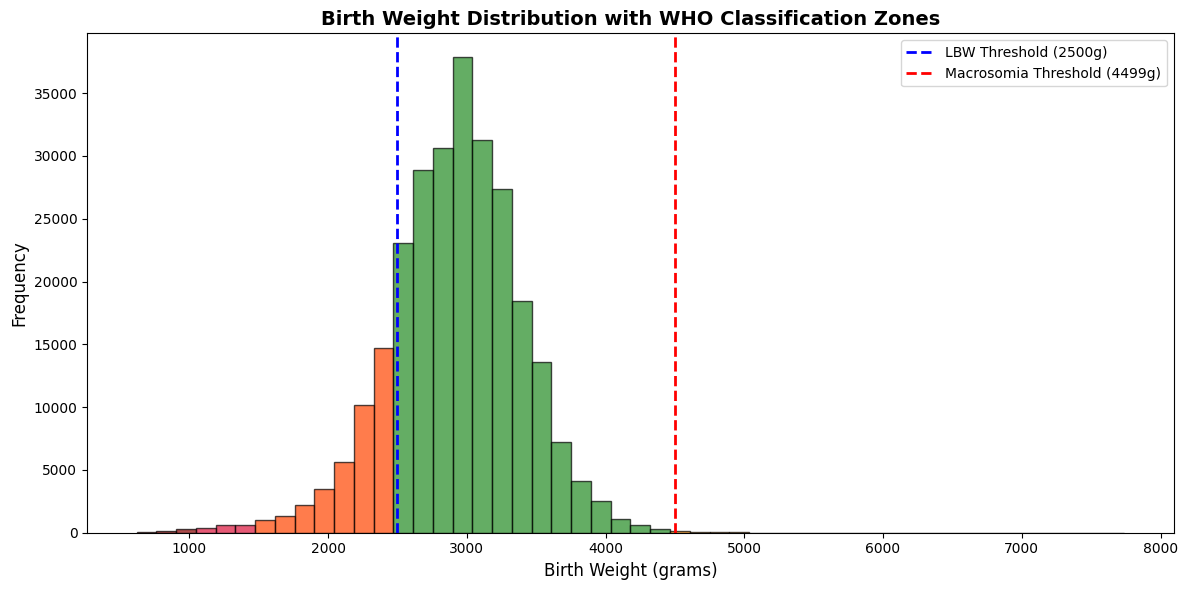

✅ Saved: 1_birth_weight_distribution.png


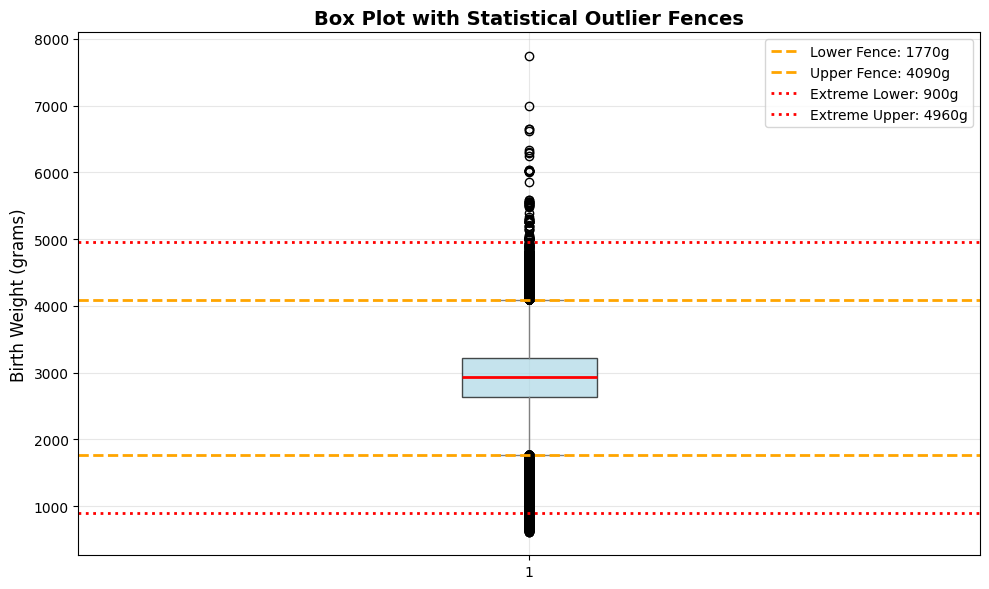

✅ Saved: 2_boxplot_fences.png


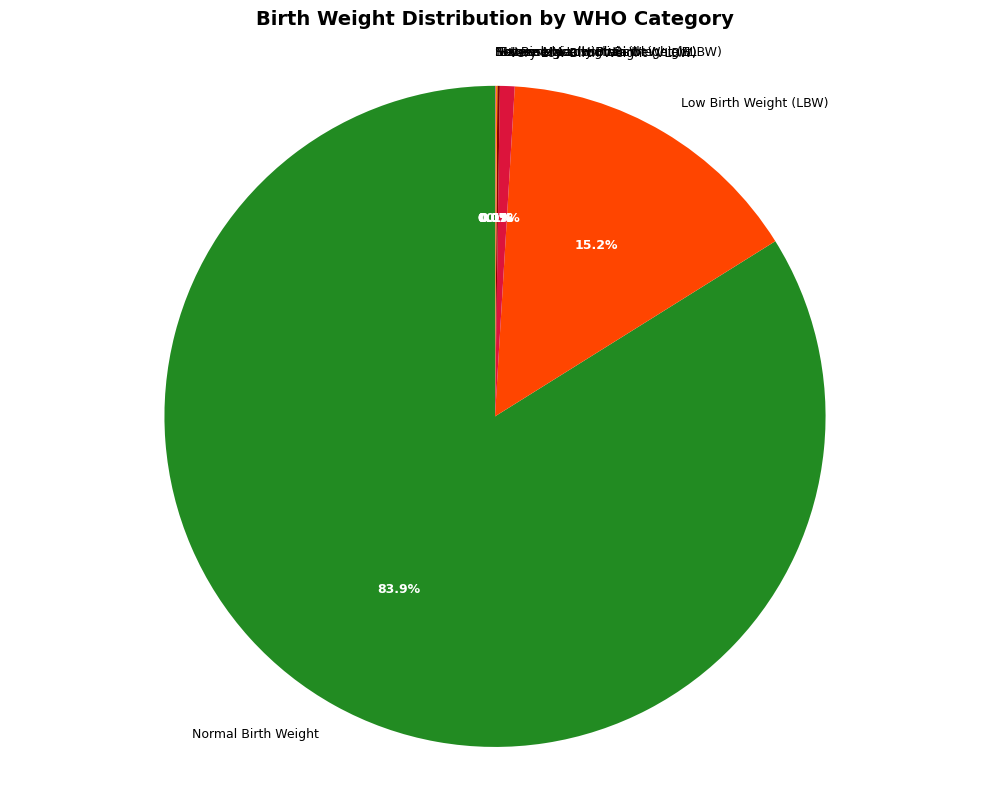

✅ Saved: 3_who_categories_pie.png


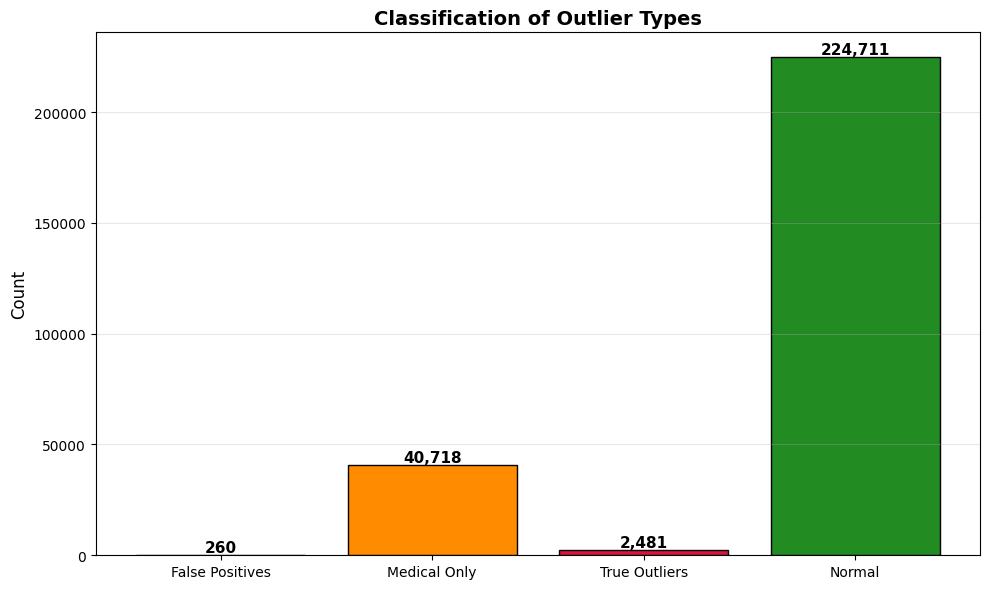

✅ Saved: 4_outlier_types.png


✅ Saved: 5_extreme_values.png


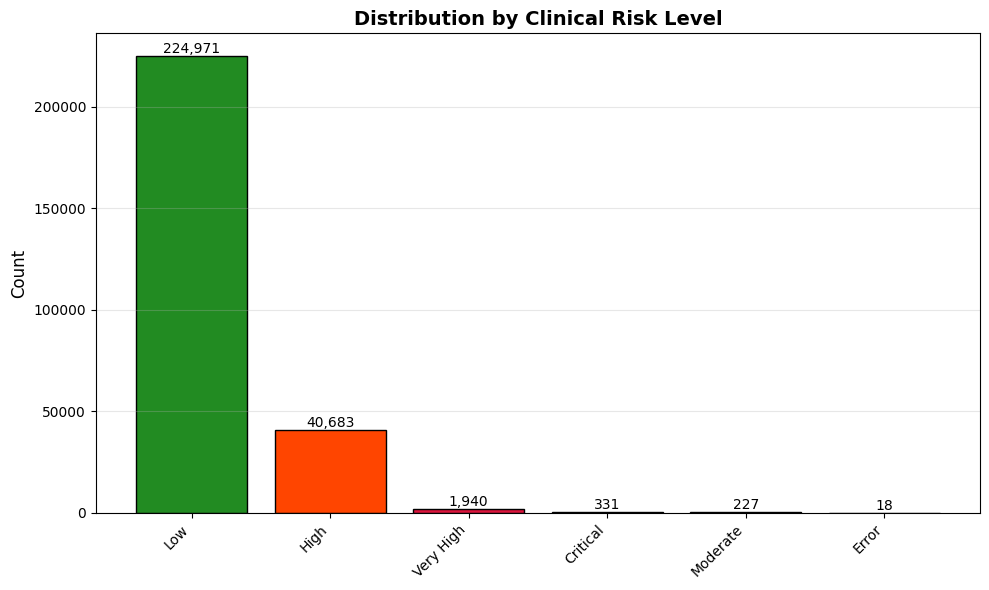

✅ Saved: 6_risk_levels.png


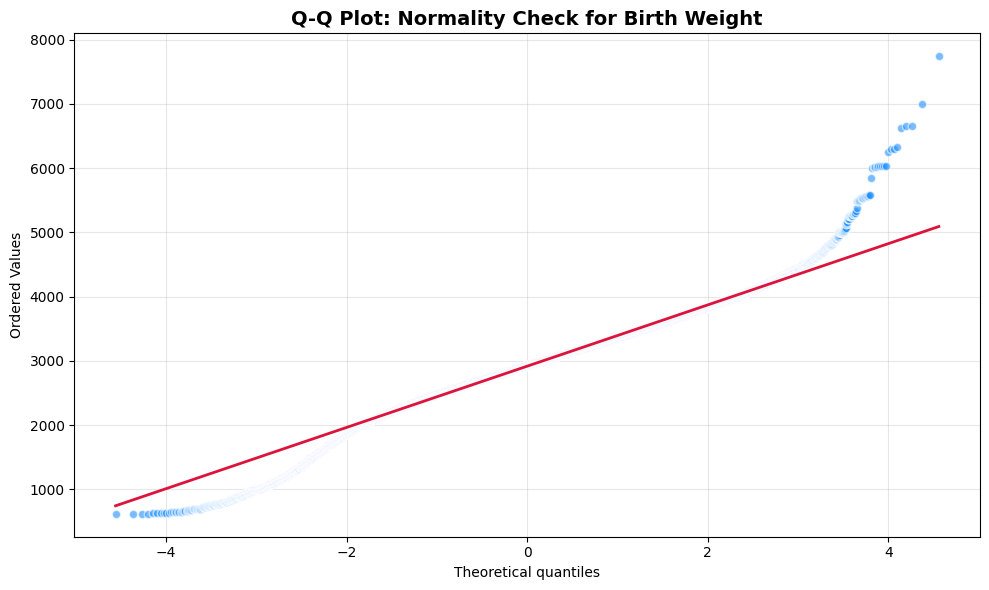

✅ Saved: 7_qq_plot.png

GENERATING TABLES
✅ Saved: table1_stat_methods.csv
✅ Saved: table2_who_summary.csv
✅ Saved: table3_outlier_types.csv
✅ Saved: table4_descriptive_stats.csv
✅ Saved: table5_extreme_values.csv

✅ ALL FILES CREATED SUCCESSFULLY

📊 GRAPHS (7 files):
   1. 1_birth_weight_distribution.png
   2. 2_boxplot_fences.png
   3. 3_who_categories_pie.png
   4. 4_outlier_types.png
   5. 5_extreme_values.png
   6. 6_risk_levels.png
   7. 7_qq_plot.png

📋 TABLES (5 files):
   8. table1_stat_methods.csv
   9. table2_who_summary.csv
   10. table3_outlier_types.csv
   11. table4_descriptive_stats.csv
   12. table5_extreme_values.csv

✅ Total: 12 files generated


In [3]:
# ============================================
# COMPLETE OUTLIER ANALYSIS WITH INDIVIDUAL GRAPHS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: LOAD YOUR DATA
# ============================================
print("Loading data...")

# Update this path to your actual file location
file_path = Path("../../../../data/raw/2020_Birth_Final.xlsx")  # Change this path
df = pd.read_excel(file_path)

# Define target variable
TARGET = 'Birth_Weight(grams)'  # Change if needed

# Get data
data = df[TARGET].dropna()
original_data = df[TARGET]

print(f"✅ Data loaded: {len(data)} valid records")

# ============================================
# STEP 2: STATISTICAL OUTLIER DETECTION
# ============================================
print("\nCalculating statistical outliers...")

# Method 1: IQR Method
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
lower_fence_extreme = Q1 - 3 * IQR
upper_fence_extreme = Q3 + 3 * IQR

iqr_outliers = data[(data < lower_fence) | (data > upper_fence)]
extreme_iqr_outliers = data[(data < lower_fence_extreme) | (data > upper_fence_extreme)]

# Method 2: Z-score method
z_scores = np.abs(stats.zscore(data))
z_outliers = data[z_scores > 3]
z_extreme = data[z_scores > 4]

# Method 3: Modified Z-score
median = data.median()
mad = np.median(np.abs(data - median))
if mad > 0:
    modified_z = 0.6745 * (data - median) / mad
else:
    modified_z = np.zeros_like(data)
mod_z_outliers = data[np.abs(modified_z) > 3.5]

print("✅ Statistical calculations complete")

# ============================================
# STEP 3: MEDICAL CLASSIFICATION
# ============================================
print("\nClassifying by WHO categories...")

# Birth weight thresholds (WHO)
medical_thresholds = {
    'Extremely Low Birth Weight (ELBW)': {
        'min': 0, 'max': 999, 
        'color': '#8B0000', 'risk': 'Critical',
        'description': 'Extremely high risk - requires intensive care',
        'action': 'Immediate NICU admission'
    },
    'Very Low Birth Weight (VLBW)': {
        'min': 1000, 'max': 1499, 
        'color': '#DC143C', 'risk': 'Very High',
        'description': 'Very high risk - requires specialized care',
        'action': 'NICU admission required'
    },
    'Low Birth Weight (LBW)': {
        'min': 1500, 'max': 2499, 
        'color': '#FF4500', 'risk': 'High',
        'description': 'Moderate risk - may require monitoring',
        'action': 'Special care nursery'
    },
    'Normal Birth Weight': {
        'min': 2500, 'max': 4499, 
        'color': '#228B22', 'risk': 'Low',
        'description': 'Healthy weight range',
        'action': 'Routine care'
    },
    'Macrosomia (High Birth Weight)': {
        'min': 4500, 'max': 4999, 
        'color': '#FF8C00', 'risk': 'Moderate',
        'description': 'Risk of birth complications',
        'action': 'Monitor for shoulder dystocia'
    },
    'Severe Macrosomia': {
        'min': 5000, 'max': 5499, 
        'color': '#FF1493', 'risk': 'High',
        'description': 'Very high risk of complications',
        'action': 'Prepare for C-section'
    },
    'Extreme Macrosomia': {
        'min': 5500, 'max': 5999, 
        'color': '#800080', 'risk': 'Very High',
        'description': 'Exceptional cases, extremely rare',
        'action': 'Multidisciplinary team required'
    },
    'Not Biologically Plausible': {
        'min': 6000, 'max': float('inf'), 
        'color': '#000000', 'risk': 'Error',
        'description': 'Likely data entry error',
        'action': 'Verify source data'
    }
}

# Create classification DataFrame
classification = []
for value in data:
    for category, details in medical_thresholds.items():
        if details['min'] <= value <= details['max']:
            classification.append({
                'value': value,
                'medical_category': category,
                'risk_level': details['risk'],
                'description': details['description'],
                'action': details['action'],
                'color': details['color']
            })
            break

class_df = pd.DataFrame(classification)

# Add statistical flags
class_df['z_score'] = np.abs(stats.zscore(class_df['value']))
class_df['is_iqr_outlier'] = class_df['value'].isin(iqr_outliers)
class_df['is_extreme_iqr'] = class_df['value'].isin(extreme_iqr_outliers)
class_df['is_z_outlier'] = class_df['value'].isin(z_outliers)
class_df['is_mod_z_outlier'] = class_df['value'].isin(mod_z_outliers)

class_df['methods_count'] = (
    class_df['is_iqr_outlier'].astype(int) + 
    class_df['is_extreme_iqr'].astype(int) + 
    class_df['is_z_outlier'].astype(int) + 
    class_df['is_mod_z_outlier'].astype(int)
)
class_df['is_stat_outlier'] = class_df['methods_count'] >= 2
class_df['is_extreme_stat'] = class_df['is_extreme_iqr'] | (class_df['z_score'] > 4)

print("✅ Classification complete")

# ============================================
# STEP 4: IDENTIFY OUTLIER TYPES
# ============================================
print("\nIdentifying outlier types...")

# Type 1: Statistical outliers that are medically normal
false_positives = class_df[
    (class_df['is_stat_outlier']) & 
    (class_df['medical_category'] == 'Normal Birth Weight')
]

# Type 2: Medical outliers that are not statistical outliers
medical_only = class_df[
    (~class_df['is_stat_outlier']) & 
    (class_df['medical_category'] != 'Normal Birth Weight')
]

# Type 3: Both statistical and medical outliers
true_outliers = class_df[
    (class_df['is_stat_outlier']) & 
    (class_df['medical_category'] != 'Normal Birth Weight')
]

# Type 4: Extreme low birth weight (<1500g)
extreme_low = class_df[
    (class_df['medical_category'].isin(['Extremely Low Birth Weight (ELBW)', 'Very Low Birth Weight (VLBW)']))
]

# Type 5: Extreme high birth weight (≥5000g)
extreme_high = class_df[
    (class_df['medical_category'].isin(['Severe Macrosomia', 'Extreme Macrosomia']))
]

# Type 6: Biologically implausible values
implausible = class_df[
    (class_df['medical_category'] == 'Not Biologically Plausible') |
    (class_df['value'] < 300)
]

print("✅ Outlier types identified")

# ============================================
# STEP 5: GENERATE INDIVIDUAL GRAPHS
# ============================================
print("\n" + "="*60)
print("GENERATING INDIVIDUAL GRAPHS")
print("="*60)

# Graph 1: Distribution Histogram with WHO Zones
plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(data, bins=50, edgecolor='black', alpha=0.7)

for i in range(len(bins)-1):
    bin_center = (bins[i] + bins[i+1]) / 2
    if bin_center < 1000:
        patches[i].set_facecolor('#8B0000')
    elif bin_center < 1500:
        patches[i].set_facecolor('#DC143C')
    elif bin_center < 2500:
        patches[i].set_facecolor('#FF4500')
    elif bin_center <= 4499:
        patches[i].set_facecolor('#228B22')
    elif bin_center <= 4999:
        patches[i].set_facecolor('#FF8C00')
    elif bin_center <= 5499:
        patches[i].set_facecolor('#FF1493')
    else:
        patches[i].set_facecolor('#800080')

plt.axvline(x=2500, color='blue', linestyle='--', linewidth=2, label='LBW Threshold (2500g)')
plt.axvline(x=4499, color='red', linestyle='--', linewidth=2, label='Macrosomia Threshold (4499g)')
plt.xlabel('Birth Weight (grams)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Birth Weight Distribution with WHO Classification Zones', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('1_birth_weight_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 1_birth_weight_distribution.png")

# Graph 2: Box Plot with Statistical Fences
plt.figure(figsize=(10, 6))
bp = plt.boxplot(data, patch_artist=True, showfliers=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
bp['whiskers'][0].set_color('gray')
bp['whiskers'][1].set_color('gray')
bp['caps'][0].set_color('gray')
bp['caps'][1].set_color('gray')
bp['medians'][0].set_color('red')
bp['medians'][0].set_linewidth(2)

plt.axhline(y=lower_fence, color='orange', linestyle='--', linewidth=2, 
            label=f'Lower Fence: {lower_fence:.0f}g')
plt.axhline(y=upper_fence, color='orange', linestyle='--', linewidth=2, 
            label=f'Upper Fence: {upper_fence:.0f}g')
plt.axhline(y=lower_fence_extreme, color='red', linestyle=':', linewidth=2, 
            label=f'Extreme Lower: {lower_fence_extreme:.0f}g')
plt.axhline(y=upper_fence_extreme, color='red', linestyle=':', linewidth=2, 
            label=f'Extreme Upper: {upper_fence_extreme:.0f}g')

plt.ylabel('Birth Weight (grams)', fontsize=12)
plt.title('Box Plot with Statistical Outlier Fences', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('2_boxplot_fences.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 2_boxplot_fences.png")

# Graph 3: Pie Chart - WHO Categories
plt.figure(figsize=(10, 8))
category_counts = class_df['medical_category'].value_counts()
colors = [medical_thresholds[cat]['color'] for cat in category_counts.index]

wedges, texts, autotexts = plt.pie(category_counts.values, 
                                     labels=category_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     startangle=90,
                                     textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Birth Weight Distribution by WHO Category', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.savefig('3_who_categories_pie.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 3_who_categories_pie.png")

# Graph 4: Bar Chart - Outlier Types
plt.figure(figsize=(10, 6))
outlier_types = {
    'False Positives': len(false_positives),
    'Medical Only': len(medical_only),
    'True Outliers': len(true_outliers),
    'Normal': len(data) - len(false_positives) - len(medical_only) - len(true_outliers)
}
colors = ['#1E90FF', '#FF8C00', '#DC143C', '#228B22']
bars = plt.bar(outlier_types.keys(), outlier_types.values(), color=colors, edgecolor='black')

for bar, value in zip(bars, outlier_types.values()):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{value:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Count', fontsize=12)
plt.title('Classification of Outlier Types', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('4_outlier_types.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 4_outlier_types.png")

# Graph 5: Scatter Plot - Extreme Values
plt.figure(figsize=(12, 6))
extreme_values = class_df[
    (class_df['medical_category'].isin(['Extremely Low Birth Weight (ELBW)', 
                                        'Very Low Birth Weight (VLBW)',
                                        'Severe Macrosomia', 
                                        'Extreme Macrosomia',
                                        'Not Biologically Plausible']))
]

if len(extreme_values) > 0:
    colors = [medical_thresholds[cat]['color'] for cat in extreme_values['medical_category']]
    sizes = [100 if 'Extreme' in cat or 'Not' in cat else 70 for cat in extreme_values['medical_category']]
    
    plt.scatter(range(len(extreme_values)), extreme_values['value'], 
                c=colors, s=sizes, alpha=0.7, edgecolor='white', linewidth=1)
    
    plt.axhline(y=2500, color='green', linestyle='--', linewidth=2, label='Normal Range Start (2500g)')
    plt.axhline(y=4499, color='green', linestyle='--', linewidth=2, label='Normal Range End (4499g)')
    plt.axhline(y=1500, color='orange', linestyle=':', linewidth=2, label='VLBW Threshold (1500g)')
    plt.axhline(y=5000, color='red', linestyle=':', linewidth=2, label='Severe Macrosomia (5000g)')
    
    plt.xlabel('Extreme Value Index', fontsize=12)
    plt.ylabel('Birth Weight (grams)', fontsize=12)
    plt.title('Extreme Birth Weight Values', fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    for idx, row in extreme_values.iterrows():
        if row['value'] > 5500 or row['value'] < 800:
            plt.text(idx, row['value'] + 100, f"{row['value']:.0f}g", 
                    fontsize=8, ha='center')

plt.tight_layout()
plt.savefig('5_extreme_values.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 5_extreme_values.png")

# Graph 6: Risk Level Distribution
plt.figure(figsize=(10, 6))
risk_counts = class_df['risk_level'].value_counts()
risk_colors = {
    'Critical': '#8B0000', 
    'Very High': '#DC143C', 
    'High': '#FF4500',
    'Moderate': '#FF8C00', 
    'Low': '#228B22', 
    'Error': '#000000'
}
colors = [risk_colors.get(risk, 'gray') for risk in risk_counts.index]

bars = plt.bar(range(len(risk_counts)), risk_counts.values, color=colors, edgecolor='black')
plt.xticks(range(len(risk_counts)), risk_counts.index, rotation=45, ha='right')
plt.ylabel('Count', fontsize=12)
plt.title('Distribution by Clinical Risk Level', fontsize=14, fontweight='bold')

for bar, count in zip(bars, risk_counts.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('6_risk_levels.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 6_risk_levels.png")

# Graph 7: Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(data, dist="norm", plot=plt)
plt.gca().get_lines()[0].set_markerfacecolor('#1E90FF')
plt.gca().get_lines()[0].set_markeredgecolor('white')
plt.gca().get_lines()[0].set_alpha(0.6)
plt.gca().get_lines()[1].set_color('#DC143C')
plt.gca().get_lines()[1].set_linewidth(2)
plt.title('Q-Q Plot: Normality Check for Birth Weight', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('7_qq_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 7_qq_plot.png")

# ============================================
# STEP 6: GENERATE TABLES
# ============================================
print("\n" + "="*60)
print("GENERATING TABLES")
print("="*60)

# Table 1: Statistical Methods Comparison
comparison_data = {
    'Method': ['IQR (1.5x)', 'Extreme IQR (3x)', 'Z-score (>3)', 'Modified Z-score', 'Consensus'],
    'Outliers Count': [
        len(iqr_outliers),
        len(extreme_iqr_outliers),
        len(z_outliers),
        len(mod_z_outliers),
        len(class_df[class_df['is_stat_outlier']])
    ],
    'Percentage': [
        f"{len(iqr_outliers)/len(data)*100:.2f}%",
        f"{len(extreme_iqr_outliers)/len(data)*100:.2f}%",
        f"{len(z_outliers)/len(data)*100:.2f}%",
        f"{len(mod_z_outliers)/len(data)*100:.2f}%",
        f"{len(class_df[class_df['is_stat_outlier']])/len(data)*100:.2f}%"
    ]
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv('table1_stat_methods.csv', index=False)
print("✅ Saved: table1_stat_methods.csv")

# Table 2: WHO Categories Summary
who_table = class_df.groupby(['medical_category', 'risk_level']).agg({
    'value': ['count', 'mean', 'min', 'max'],
    'is_stat_outlier': 'sum'
}).round(1)
who_table.columns = ['Count', 'Mean (g)', 'Min (g)', 'Max (g)', 'Statistical Outliers']
who_table = who_table.reset_index()
who_table.to_csv('table2_who_summary.csv', index=False)
print("✅ Saved: table2_who_summary.csv")

# Table 3: Outlier Types Details
outlier_details = pd.DataFrame({
    'Outlier Type': ['False Positives', 'Medical Only', 'True Outliers', 'Extreme Low', 'Extreme High', 'Implausible'],
    'Count': [
        len(false_positives),
        len(medical_only),
        len(true_outliers),
        len(extreme_low),
        len(extreme_high),
        len(implausible)
    ],
    'Percentage': [
        f"{len(false_positives)/len(data)*100:.2f}%",
        f"{len(medical_only)/len(data)*100:.2f}%",
        f"{len(true_outliers)/len(data)*100:.2f}%",
        f"{len(extreme_low)/len(data)*100:.2f}%",
        f"{len(extreme_high)/len(data)*100:.2f}%",
        f"{len(implausible)/len(data)*100:.2f}%"
    ],
    'Description': [
        'Statistical outliers but medically normal',
        'Medically abnormal but not statistical outliers',
        'Both statistical and medical outliers',
        'Very low birth weight (<1500g)',
        'Very high birth weight (≥5000g)',
        'Biologically impossible values'
    ]
})
outlier_details.to_csv('table3_outlier_types.csv', index=False)
print("✅ Saved: table3_outlier_types.csv")

# Table 4: Descriptive Statistics
stats_table = pd.DataFrame({
    'Statistic': ['Count', 'Mean', 'Median', 'Mode', 'Std Dev', 'Min', 'Max', 'Range', 'Q1', 'Q3', 'IQR', 'Skewness'],
    'Value': [
        len(data),
        f"{data.mean():.1f}",
        f"{data.median():.1f}",
        f"{data.mode().values[0]:.1f}" if len(data.mode()) > 0 else 'N/A',
        f"{data.std():.1f}",
        f"{data.min():.1f}",
        f"{data.max():.1f}",
        f"{data.max() - data.min():.1f}",
        f"{Q1:.1f}",
        f"{Q3:.1f}",
        f"{IQR:.1f}",
        f"{data.skew():.3f}"
    ]
})
stats_table.to_csv('table4_descriptive_stats.csv', index=False)
print("✅ Saved: table4_descriptive_stats.csv")

# Table 5: Extreme Values List
if len(extreme_values) > 0:
    extreme_list = extreme_values[['value', 'medical_category', 'risk_level', 'z_score']].copy()
    extreme_list = extreme_list.sort_values('value', ascending=False)
    extreme_list['z_score'] = extreme_list['z_score'].round(2)
    extreme_list.to_csv('table5_extreme_values.csv', index=False)
    print("✅ Saved: table5_extreme_values.csv")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("✅ ALL FILES CREATED SUCCESSFULLY")
print("="*60)
print("\n📊 GRAPHS (7 files):")
print("   1. 1_birth_weight_distribution.png")
print("   2. 2_boxplot_fences.png")
print("   3. 3_who_categories_pie.png")
print("   4. 4_outlier_types.png")
print("   5. 5_extreme_values.png")
print("   6. 6_risk_levels.png")
print("   7. 7_qq_plot.png")

print("\n📋 TABLES (5 files):")
print("   8. table1_stat_methods.csv")
print("   9. table2_who_summary.csv")
print("   10. table3_outlier_types.csv")
print("   11. table4_descriptive_stats.csv")
print("   12. table5_extreme_values.csv")

print("\n✅ Total: 12 files generated")
print("="*60)